<a href="https://colab.research.google.com/github/IAT-ExploringAI-2026/Computer-Vision-Project/blob/main/ComputerVisionProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><h1> <b> Object Detection Using YOLO <b> </h1></center>

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    pass  # running locally, not on Colab

This tutorial is designed to provide a comprehensive understanding of how to use YOLO, a state-of-the-art method in computer vision, for detecting objects in images.

Object detection and classification is a key technology in many areas, such as automated vehicles, security, and even healthcare.

We will begin with the basics of preparing (pre processing) an image dataset, ensuring it is ready for effective model training.We will then explore how YOLO, a type of convolutional neural network, automatically extracts features from images to recognize different objects. Understanding this process is crucial for grasping how YOLO operates.

The core of this tutorial is focused on transfer learning using YOLO. We will teach you how to take a pre-trained YOLO model and adapt it to a new dataset. This technique is efficient and powerful, allowing us to harness the strengths of YOLO with less computational effort.

By the end of this tutorial, you will have hands-on experience with preparing data, implementing YOLO, and understanding the principles behind it. This tutorial aims to equip students with practical skills and knowledge in one of the most exciting fields in technology.

Since its inception, the YOLO family of object detection models has come a long way. YOLOv8 is the most recent addition to this famous anchor-based single-shot family of object detectors. It comes with a bunch of improvements which include state-of-the-art accuracy and speed.  In this article, we will be fine tuning the YOLOv8 object detection model on a real-world pothole detection dataset.

In the previous lecture, you were asked to make your own custom datasets for a project you want to work on. Today we will explore how to finetune YOLO on a certain dataset.  

Importing required Libraries

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import cv2
import seaborn as sns
import glob
import xml.etree.ElementTree as ET
from PIL import Image
import os
import shutil

In [ ]:
# Project paths and a few imports on top of the tutorial's.
from pathlib import Path
from collections import Counter, defaultdict
import json, torch
from PIL import ImageDraw, ImageOps

def imread(p):
    # open an image respecting its EXIF rotation so photos display upright
    return ImageOps.exif_transpose(Image.open(p)).convert("RGB")

DATASETS    = Path("datasets")
MERGED      = DATASETS / "merged-6class"                      # cleaned 6-class base
FEATURED    = DATASETS / "merged-6class-balbio"               # featured dataset (balanced + real-food bio)
RAW_GC3     = DATASETS / "roboflow-garbage-classification-3"  # raw studio source (pre-clean)
TACO        = DATASETS / "TACO"
ORGANIC     = DATASETS / "eval/organic-waste"
MULTITRASH  = DATASETS / "multitrash"
HOUSEHOLD   = DATASETS / "household-trash-recycling"
WEIGHTS_DIR = Path("weights")
TEST_IMG    = Path("dataset/images/test")
CLASSES = ["BIODEGRADABLE", "CARDBOARD", "GLASS", "METAL", "PAPER", "PLASTIC"]
DEVICE = "mps" if torch.backends.mps.is_available() else (0 if torch.cuda.is_available() else "cpu") # anh runs this on his mac so he needs mps.
print("device:", DEVICE)

device: mps


# Dataset Description






Waste Images for Object Detection

Our data came from multiple public sources.

We sort household waste into six material classes: BIODEGRADABLE, CARDBOARD, GLASS, METAL, PAPER, PLASTIC. Online datasets are train/validation; our own captured photos (about 30 per group member) are the test split.

| Source | Used for | Notes |
|---|---|---|
| Roboflow "Garbage Classification 3" | train / valid | primary source, exact 6 class names, mostly white studio photos |
| TACO | train / valid | real-world litter in context (streets, nature) |
| cardboard-eupc8 | train / valid | extra cardboard, one of the two smallest classes |
| paper-recyclability | train / valid | extra paper, the other small class |
| Organic Waste Detection | train / valid | real-background food waste, replaces the studio biodegradable |
| Our own photos | test | about 30 per member, real backgrounds |

We'll preprocess them later below.

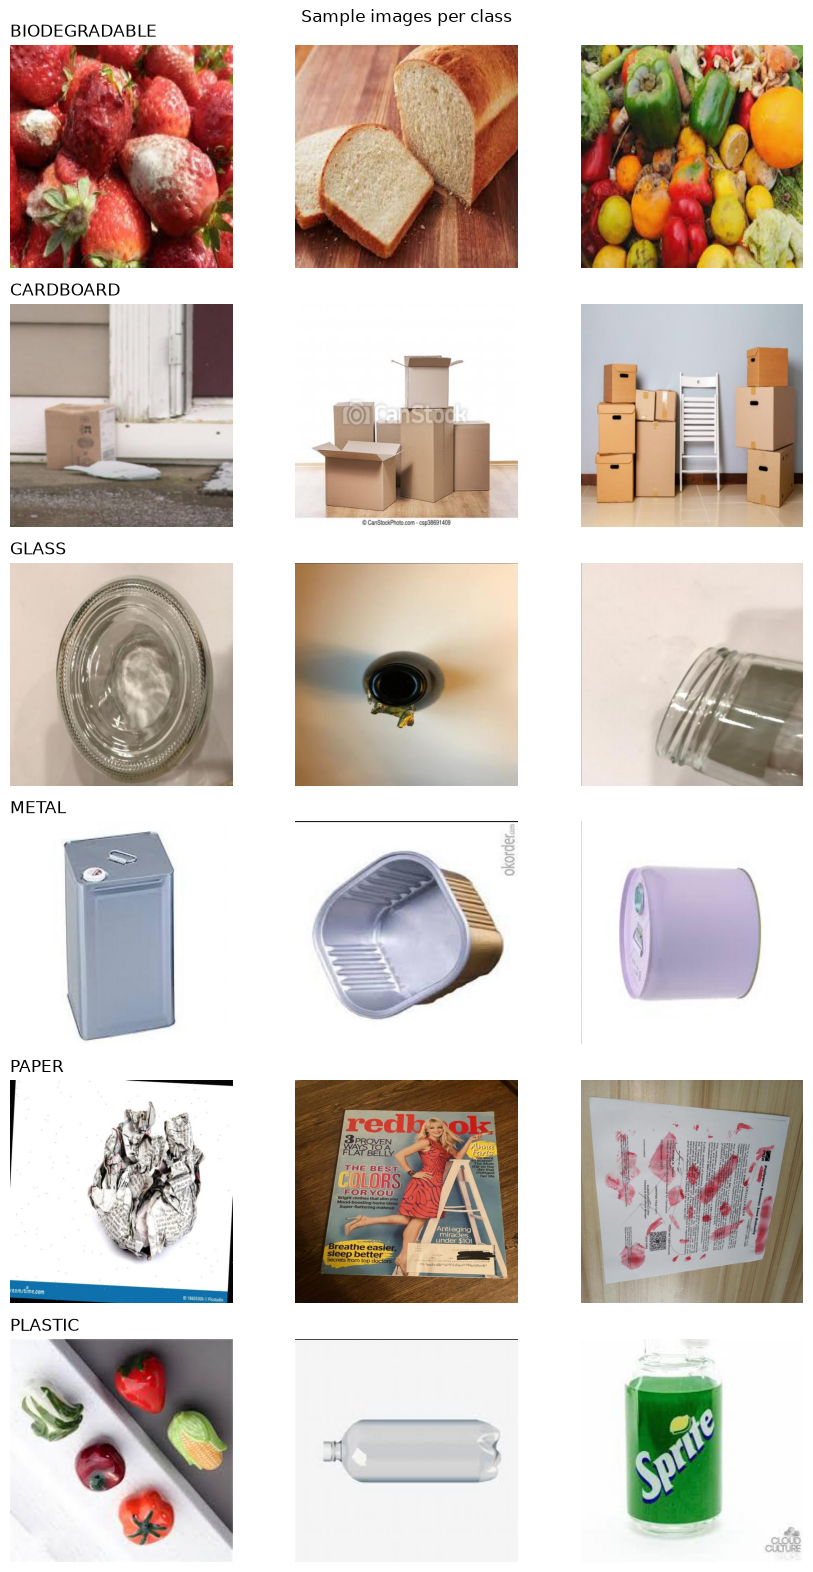

In [ ]:
# Sample images per class
def sample_per_class(root, per=3):
    lbl, img = root/"train"/"labels", root/"train"/"images"
    picks = {c: [] for c in range(6)}
    for t in sorted(lbl.glob("*.txt")):
        cls = {int(l.split()[0]) for l in t.read_text().splitlines() if l.split()}
        if len(cls) != 1: continue
        c = cls.pop()
        if len(picks[c]) < per:
            p = next(img.glob(t.stem + ".*"), None)
            if p: picks[c].append(p)
        if all(len(v) >= per for v in picks.values()): break
    return picks

picks = sample_per_class(MERGED)
fig, axes = plt.subplots(6, 3, figsize=(9, 16))
for r, c in enumerate(range(6)):
    for k in range(3):
        ax = axes[r][k]; ax.axis("off")
        if k < len(picks[c]): ax.imshow(imread(picks[c][k]))
        if k == 0: ax.set_title(CLASSES[c], loc="left", color="black")
plt.suptitle("Sample images per class"); plt.tight_layout(); plt.show()

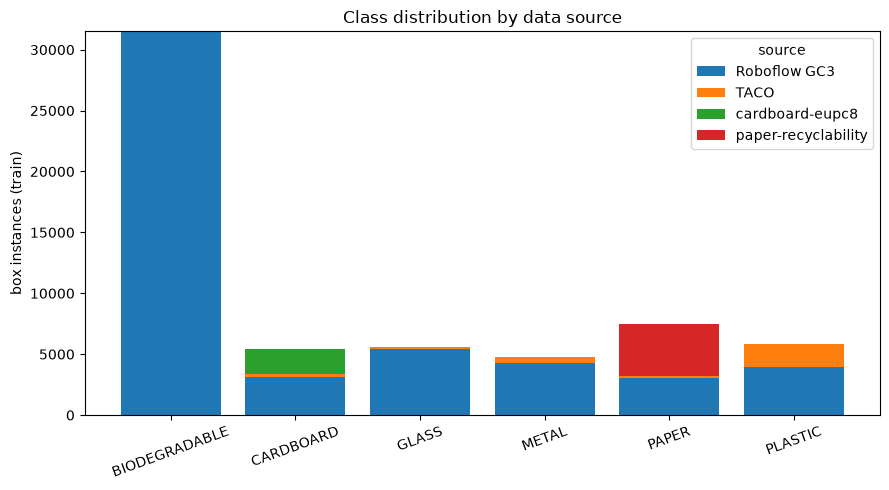

{'BIODEGRADABLE': 31508, 'CARDBOARD': 5451, 'GLASS': 5625, 'METAL': 4789, 'PAPER': 7500, 'PLASTIC': 5877}


In [ ]:
# Class distribution by source
SOURCES = {"rf":"Roboflow GC3", "taco":"TACO", "card":"cardboard-eupc8", "paper":"paper-recyclability"}
by = {s: Counter() for s in SOURCES}
for t in (MERGED/"train"/"labels").glob("*.txt"):
    pre = t.name.split("__")[0]; pre = pre if pre in SOURCES else "rf"
    for l in t.read_text().splitlines():
        p = l.split()
        if p: by[pre][int(float(p[0]))] += 1
bottom = np.zeros(6); plt.figure(figsize=(9,5))
for s, name in SOURCES.items():
    v = np.array([by[s].get(i,0) for i in range(6)])
    plt.bar(CLASSES, v, bottom=bottom, label=name); bottom += v
plt.ylabel("box instances (train)"); plt.title("Class distribution by data source")
plt.legend(title="source"); plt.xticks(rotation=20); plt.tight_layout(); plt.show()
print({CLASSES[i]: int(bottom[i]) for i in range(6)})

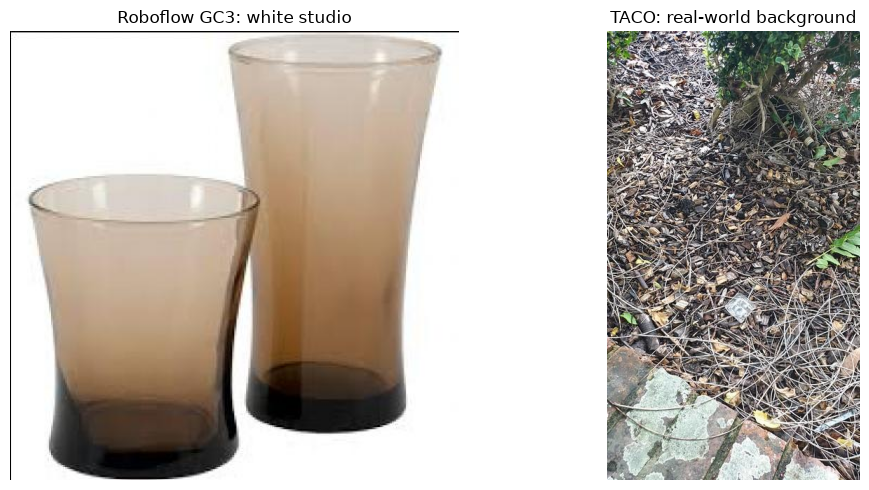

In [ ]:
# Some sources use white studio backgrounds, others use real-world backgrounds.
studio = next((RAW_GC3/"train"/"images").glob("glass*.jpg"), None) or next((RAW_GC3/"train"/"images").glob("*.jpg"))
real   = next((TACO/"yolo"/"images").glob("*.jpg"))
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].imshow(imread(studio)); ax[0].set_title("Roboflow GC3: white studio"); ax[0].axis("off")
ax[1].imshow(imread(real));   ax[1].set_title("TACO: real-world background"); ax[1].axis("off")
plt.tight_layout(); plt.show()

# Data Preprocessing

For preprocessing:
- We have to convert the dataset into that acceptable by YOLO.
  - Heirarchy of folders should be the one accepted by YOLO
  - Labels format should be darknet YOLO.
  - Labels files should be .txt files
- Check and see if there are any missing labels or images. And remove them from dataset.




The train and test folders have all the images and labels together.

But for YOLO, the directories should be in:

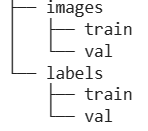


near-duplicates: 29  |  copies in more than one split: 20  |  total flagged: 49


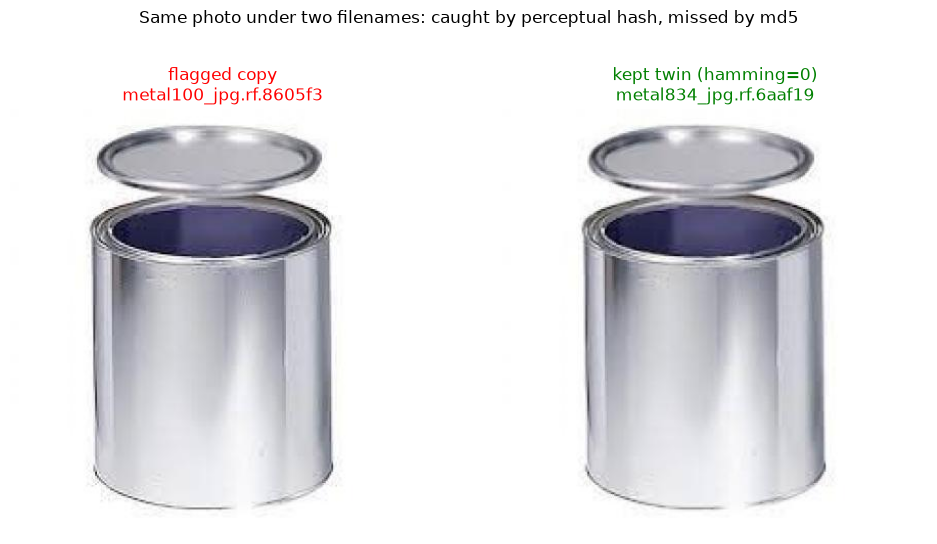

In [ ]:
# Find duplicate photos with perceptual hashing.
import imagehash
Q = RAW_GC3 / "_quarantine"
n_near = len(list((Q/"near_dup").rglob("*.jp*g")))
n_leak = len(list((Q/"leakage").rglob("*.jp*g")))
print(f"near-duplicates: {n_near}  |  copies in more than one split: {n_leak}  |  total flagged: {n_near + n_leak}")

kept = list((RAW_GC3/"train"/"images").glob("*.jpg")) + list((RAW_GC3/"valid"/"images").glob("*.jpg")) + list((RAW_GC3/"test"/"images").glob("*.jpg"))
qi = sorted((Q/"leakage").rglob("*.jp*g"))[0]
qh = imagehash.phash(Image.open(qi).convert("RGB"))
twin = min(kept, key=lambda k: qh - imagehash.phash(Image.open(k).convert("RGB")))
ham = qh - imagehash.phash(Image.open(twin).convert("RGB"))
fig, ax = plt.subplots(1, 2, figsize=(10, 5.5))
ax[0].imshow(imread(qi));   ax[0].set_title(f"flagged copy\n{qi.name[:22]}", color="red");  ax[0].axis("off")
ax[1].imshow(imread(twin)); ax[1].set_title(f"kept twin (hamming={ham})\n{twin.name[:22]}", color="green"); ax[1].axis("off")
fig.suptitle("Same photo under two filenames")
plt.tight_layout(rect=[0, 0, 1, 0.90]); plt.show()

In [ ]:
# Deduplicate
flagged = {p.name for p in Q.rglob("*.jp*g")}
present = {p.name for p in kept}
print(f"flagged images still in the training splits: {len(flagged & present)} (expected 0)")

flagged images still in the training splits: 0 (expected 0)


In [ ]:
# Broken labels: boxes with zero width or height.
def find_zero_area(labels_dir):
    hits = []
    for t in labels_dir.glob("*.txt"):
        for i, l in enumerate(t.read_text().splitlines()):
            p = l.split()
            if len(p) == 5 and (float(p[3]) <= 0 or float(p[4]) <= 0): hits.append((t, i, p))
    return hits
bad = find_zero_area(RAW_GC3/"train"/"labels")
print(f"zero-area boxes in raw labels: {len(bad)}")
if bad:
    t, i, p = bad[0]; print(f"example: {t.name} line {i}: {' '.join(p)}")

zero-area boxes in raw labels: 0


In [ ]:
# Fix: drop the zero-area rows.
merged_bad = sum(len(find_zero_area(MERGED/s/"labels")) for s in ["train","valid","test"])
print(f"zero-area boxes in the cleaned merged set: {merged_bad} (expected 0)")

zero-area boxes in the cleaned merged set: 0 (expected 0)


original 2049x1537 -> resized 640x480 | boxes outside frame: broken 4/4, fixed 0


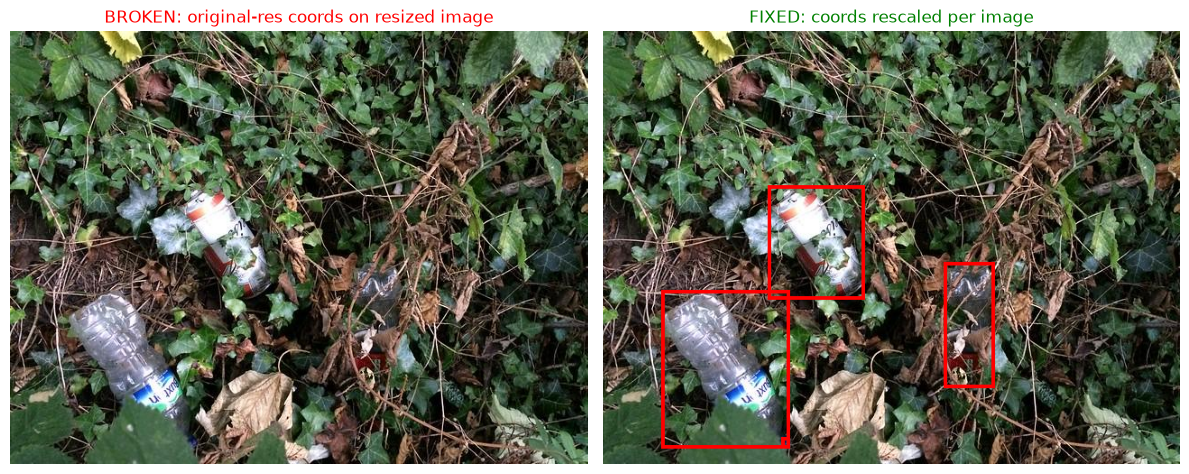

In [ ]:
# TACO bounding-box overflow: images were resized but annotations kept original-resolution
# coordinates, so most boxes fell outside the frame so we had to fix them.
ann = json.load(open(TACO/"data"/"annotations.json"))
imgs = {im["id"]: im for im in ann["images"]}
boxes_by_img = defaultdict(list)
for a in ann["annotations"]: boxes_by_img[a["image_id"]].append(a["bbox"])
yolo_dir = TACO/"yolo"/"images"
pick = next((iid for iid, b in boxes_by_img.items()
             if len(b) >= 3 and (yolo_dir/imgs[iid]["file_name"].replace("/","__")).exists()))
img_path = yolo_dir/imgs[pick]["file_name"].replace("/","__")
oW, oH = imgs[pick]["width"], imgs[pick]["height"]
im = Image.open(img_path).convert("RGB"); nW, nH = im.size
def draw(scale):
    c = im.copy(); d = ImageDraw.Draw(c); off = 0
    for x, y, w, h in boxes_by_img[pick]:
        if scale: x, y, w, h = x*nW/oW, y*nH/oH, w*nW/oW, h*nH/oH
        d.rectangle([x, y, x+w, y+h], outline=(255,0,0), width=4); off += (x > nW or y > nH)
    return c, off
broken, ob = draw(False); fixed, _ = draw(True)
print(f"original {oW}x{oH} -> resized {nW}x{nH} | boxes outside frame: broken {ob}/{len(boxes_by_img[pick])}, fixed 0")
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(broken); ax[0].set_title("BROKEN: original-res coords on resized image", color="red"); ax[0].axis("off")
ax[1].imshow(fixed);  ax[1].set_title("FIXED: coords rescaled per image", color="green"); ax[1].axis("off")
plt.tight_layout(); plt.show()

We rescale every TACO box by (resized / original) per image, bringing overflow from about 72% of boxes to 0%. We also remap TACO's 60 categories to our 6 material classes and drop non-material categories (cigarette, battery, rope, shoe, unlabeled litter).

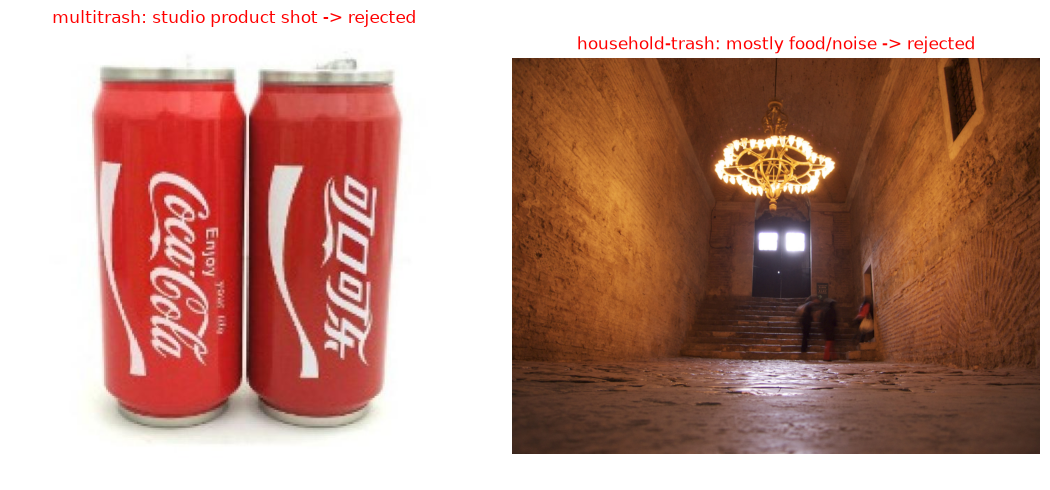

In [ ]:
# Rejected sources, shown before rejecting.
# multitrash: billed as cluttered but is largely studio product shots.
# household-trash: ~78% food boxes plus non-waste scenes; no usable material coverage.
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
mt = sorted(p for p in MULTITRASH.rglob("*.jpg") if "/labels/" not in str(p))[0]
hh = sorted(p for p in HOUSEHOLD.rglob("*.jpg") if "/labels/" not in str(p))[0]
ax[0].imshow(imread(mt)); ax[0].set_title("multitrash: studio product shot -> rejected", color="red"); ax[0].axis("off")
ax[1].imshow(imread(hh)); ax[1].set_title("household-trash: mostly food/noise -> rejected", color="red"); ax[1].axis("off")
plt.tight_layout(); plt.show()

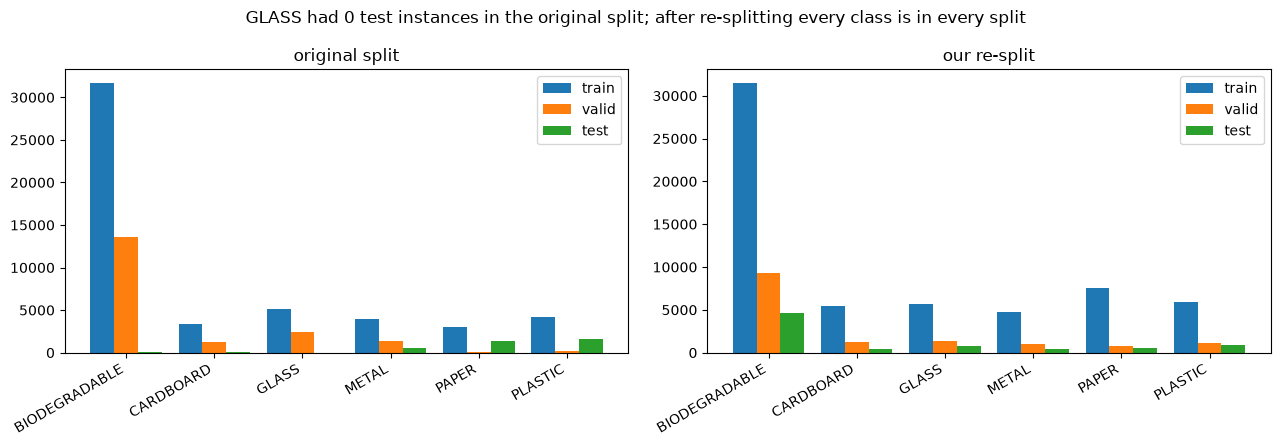

original GLASS test: 0 | re-split GLASS test: 742


In [ ]:
# Re-split: the split Roboflow shipped didn't have any GLASS in test, so per-class
# test metrics were meaningless. We re-split 70/20/10 so every class appears in every split.
def split_counts(root):
    out = {}
    for s in ["train","valid","test"]:
        c = Counter()
        for t in (root/s/"labels").glob("*.txt"):
            for l in t.read_text().splitlines():
                p = l.split()
                if p: c[int(float(p[0]))] += 1
        out[s] = c
    return out
before, after = split_counts(RAW_GC3), split_counts(MERGED)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for k, (title, cnt) in enumerate([("original split", before), ("our re-split", after)]):
    for j, s in enumerate(["train","valid","test"]):
        ax[k].bar(np.arange(6) + (j-1)*0.27, [cnt[s].get(i,0) for i in range(6)], 0.27, label=s)
    ax[k].set_xticks(range(6)); ax[k].set_xticklabels(CLASSES, rotation=30, ha="right"); ax[k].set_title(title); ax[k].legend()
plt.suptitle("GLASS had 0 test instances in the original split so we resplit them")
plt.tight_layout(); plt.show()
print("original GLASS test:", before["test"].get(2,0), "| re-split GLASS test:", after["test"].get(2,0))

In [14]:
# Cleaned base dataset summary.
for s in ["train","valid","test"]:
    ni = len(list((MERGED/s/"images").glob("*.*"))); nl = len(list((MERGED/s/"labels").glob("*.txt")))
    print(f"{s}: {ni} images / {nl} labels")

train: 12857 images / 12857 labels
valid: 2082 images / 2082 labels
test: 1042 images / 1042 labels


# balanced-bioswap model

Our featured model trains on a variant of the cleaned base with two changes: the biodegradable source is swapped, and the classes are balanced.

It is technically not our best performer. The unbalanced bio-swap model scores clearly higher on the online test sets, while on our own full test photos it is the clear winner.

## Why we swapped biodegradable

The original biodegradable images are white studio shots, and many are dense food piles with 15-20 boxes each, which inflates its share and drives false positives. We replace them with real-background food waste.

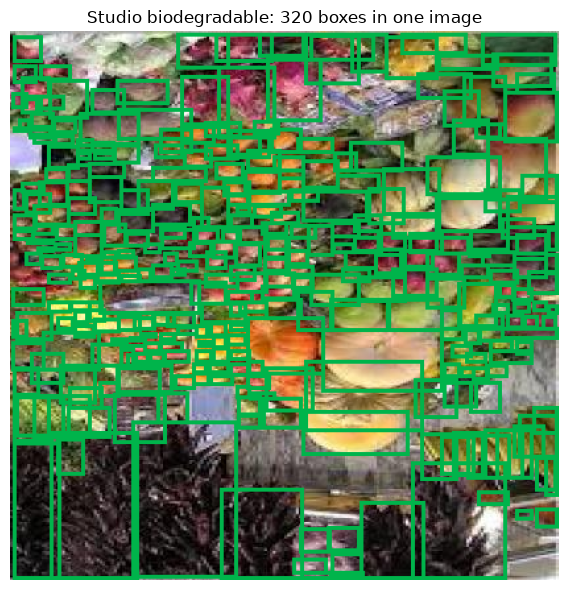

biodegradable: 31508 of 60750 boxes (52%), avg 19.2 boxes per bio image


In [ ]:
# Draw all boxes on the densest studio biodegradable image to show its problem
def bio_stats(labels_dir):
    return [(sum(1 for l in t.read_text().splitlines() if l.split() and int(float(l.split()[0]))==0), t)
            for t in labels_dir.glob("*.txt")]
stats = [s for s in bio_stats(MERGED/"train"/"labels") if s[0]]
dense = max(stats, key=lambda x: x[0])
im = Image.open(next((MERGED/"train"/"images").glob(dense[1].stem+".*"))).convert("RGB")
W, H = im.size; d = ImageDraw.Draw(im)
for l in dense[1].read_text().splitlines():
    p = l.split()
    if len(p)==5 and int(float(p[0]))==0:
        cx,cy,w,h = map(float,p[1:]); d.rectangle([(cx-w/2)*W,(cy-h/2)*H,(cx+w/2)*W,(cy+h/2)*H], outline=(0,180,75), width=3)
plt.figure(figsize=(6,6)); plt.imshow(im); plt.axis("off")
plt.title(f"Studio biodegradable: {dense[0]} boxes in one image"); plt.tight_layout(); plt.show()
tot = Counter()
for t in (MERGED/"train"/"labels").glob("*.txt"):
    for l in t.read_text().splitlines():
        p=l.split()
        if p: tot[int(float(p[0]))]+=1
print(f"biodegradable: {tot[0]} of {sum(tot.values())} boxes ({100*tot[0]/sum(tot.values()):.0f}%), avg {np.mean([n for n,_ in stats]):.1f} boxes per bio image")

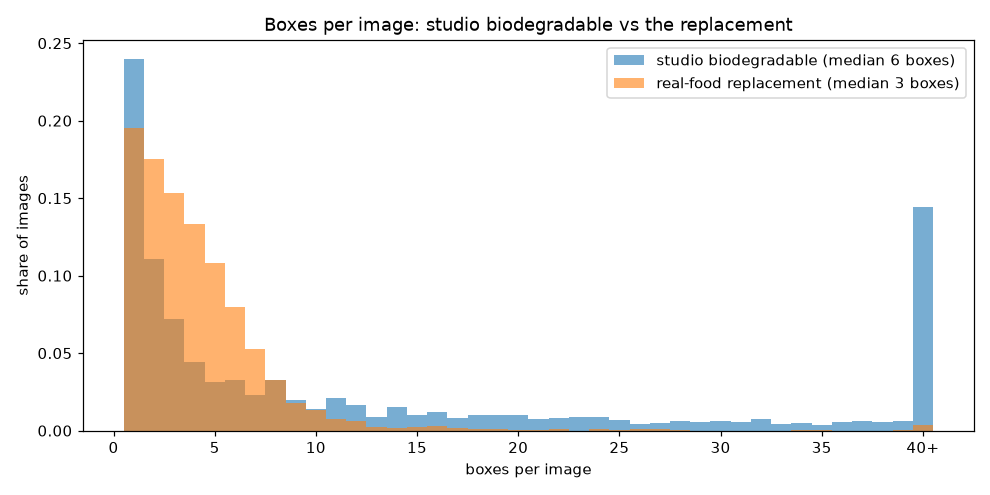

In [ ]:
# Compare studio biodegradable vs the real-food replacement dataset.
studio_counts = np.clip([n for n, _ in stats], 0, 40)
organic_counts = [sum(1 for l in t.read_text().splitlines() if l.split())
                  for t in (ORGANIC/"train"/"labels").glob("*.txt")]
organic_counts = np.clip([n for n in organic_counts if n], 0, 40)
bins = np.arange(1, 42) - 0.5
plt.figure(figsize=(9, 4.5))
plt.hist(studio_counts, bins=bins, density=True, alpha=0.6, label=f"studio biodegradable (median {int(np.median(studio_counts))} boxes)")
plt.hist(organic_counts, bins=bins, density=True, alpha=0.6, label=f"real-food replacement (median {int(np.median(organic_counts))} boxes)")
plt.xticks(list(range(0, 41, 5)), [*range(0, 40, 5), "40+"])
plt.xlabel("boxes per image"); plt.ylabel("share of images")
plt.title("Boxes per image: studio biodegradable vs the replacement")
plt.legend(); plt.tight_layout(); plt.show()

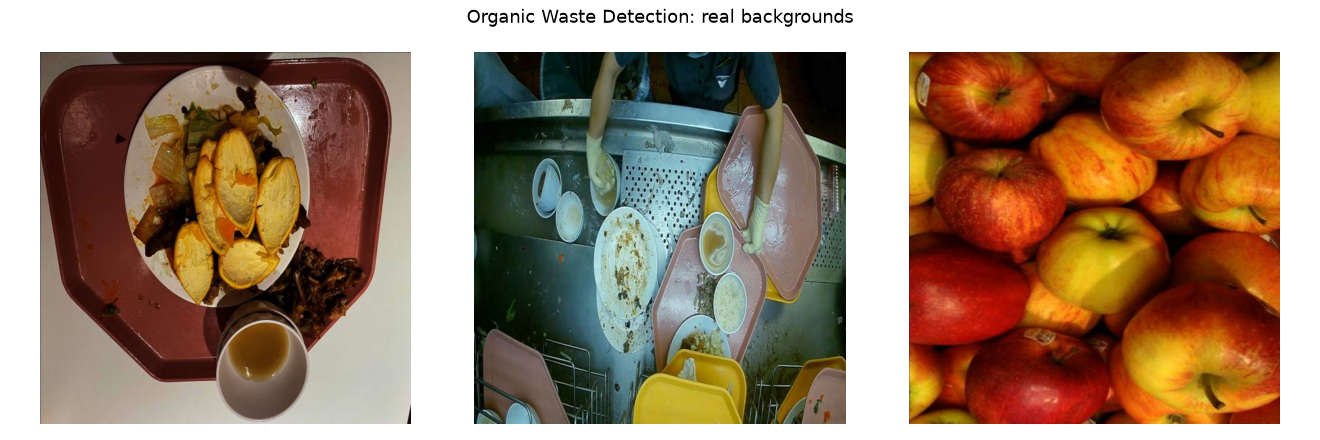

In [ ]:
# The replacement
imgs = [sorted((ORGANIC/"train"/"images").glob("*.jpg"))[i] for i in (200, 400, 2800)]
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
for k, p in enumerate(imgs): ax[k].imshow(imread(p)); ax[k].axis("off")
plt.suptitle("Organic Waste Detection: real backgrounds"); plt.tight_layout(); plt.show()

## Balancing

Biodegradable dominates (~52% of boxes). We downsample the over-represented classes to the smallest, mostly by dropping the dense food-pile images, so every class has roughly equal instances.

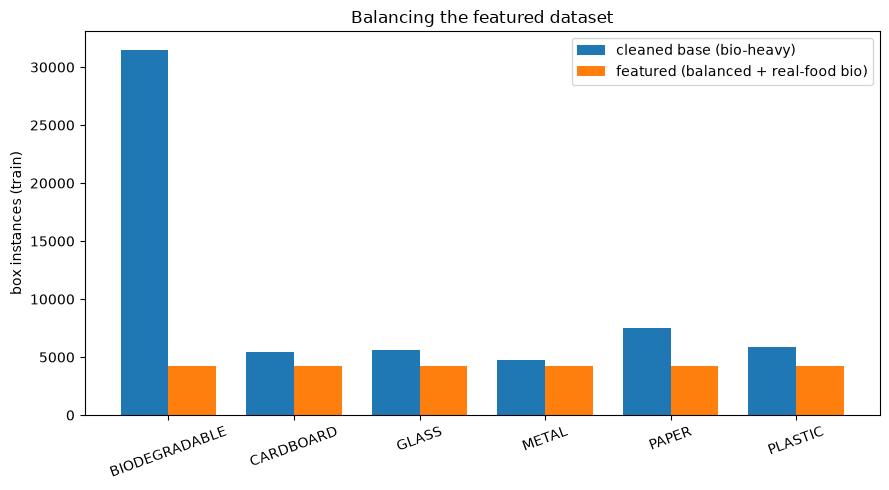

base:     {'BIODEGRADABLE': 31508, 'CARDBOARD': 5451, 'GLASS': 5625, 'METAL': 4789, 'PAPER': 7500, 'PLASTIC': 5877}
featured: {'BIODEGRADABLE': 4263, 'CARDBOARD': 4257, 'GLASS': 4244, 'METAL': 4263, 'PAPER': 4263, 'PLASTIC': 4245}


In [ ]:
def totals(labels_dir):
    c = Counter()
    for t in labels_dir.glob("*.txt"):
        for l in t.read_text().splitlines():
            p=l.split()
            if p: c[int(float(p[0]))]+=1
    return [c.get(i,0) for i in range(6)]
base_t, feat_t = totals(MERGED/"train"/"labels"), totals(FEATURED/"train"/"labels")
x = np.arange(6); w = 0.38; plt.figure(figsize=(9,5))
plt.bar(x-w/2, base_t, w, label="cleaned base (bio-heavy)")
plt.bar(x+w/2, feat_t, w, label="featured (balanced + real-food bio)")
plt.xticks(x, CLASSES, rotation=20); plt.ylabel("box instances (train)")
plt.legend(); plt.title("Balancing the featured dataset"); plt.tight_layout(); plt.show()
print("base:    ", {CLASSES[i]: base_t[i] for i in range(6)})
print("featured:", {CLASSES[i]: feat_t[i] for i in range(6)})

# Custom object detection using YOLO

First install and import

In [18]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.4.84 🚀 Python-3.11.14 torch-2.12.1 CPU (Apple M4 Pro)


Setup complete ✅ (14 CPUs, 48.0 GB RAM, 1370.1/1858.2 GB disk)


In [19]:
from ultralytics import YOLO

## Training YOLO

We are going to select small pretrained (on COCO dataset) model of YOLOv8

In [20]:
model = YOLO('yolov8s.pt') # pretrained model

The detailed architecture of the model can be seen from:


In [21]:
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, bias=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0

In [22]:
%%writefile config.yaml
path: /Users/pwign/Developer/iat360/Computer-Vision-Project-Group-9/datasets/merged-6class-balbio
train: train/images
val: valid/images
nc: 6
names: [BIODEGRADABLE, CARDBOARD, GLASS, METAL, PAPER, PLASTIC]

Writing config.yaml


Please look at [Yolo train Docs](https://docs.ultralytics.com/modes/train/#train-settings) for hyperparameters for model tuning and configuration, e.g. lr0, imgsz, model etc.

In [ ]:
# 50 epochs on a Kaggle GPU (~3h).
RUN_TRAINING = False
if RUN_TRAINING:
    model = YOLO("yolov8s.pt")
    model.train(data="config.yaml", epochs=50, batch=16, imgsz=640, lr0=0.01, device=DEVICE,
                project="runs", name="balanced_bioswap")

## Evaluation Metrics

[This](https://docs.ultralytics.com/guides/yolo-performance-metrics/) is a very good detailed explanation of different perfromance metrics in YOLO.

**Choosing the Right Metrics**

Choosing the right metrics to evaluate often depends on the specific application.

- mAP: Suitable for a broad assessment of model performance.

- IoU: Essential when precise object location is crucial.

- Precision: Important when minimizing false detections is a priority.

- Recall: Vital when it's important to detect every instance of an object.

- F1 Score: Useful when a balance between precision and recall is needed.


In [24]:
# Load our fine-tuned featured model and evaluate live (recomputes metrics + confusion matrix).
model = YOLO(str(WEIGHTS_DIR/"balanced_bioswap.pt"))
open("val.yaml","w").write(f"path: {FEATURED.resolve()}\ntrain: train/images\nval: valid/images\nnc: 6\nnames: {CLASSES}\n")
metrics = model.val(data="val.yaml", split="val", device=DEVICE, plots=True, verbose=False)
print(f"mAP50 = {metrics.box.map50:.3f}   mAP50-95 = {metrics.box.map:.3f}")
metrics.box.map, metrics.box.map50, metrics.box.map75

Ultralytics 8.4.84 🚀 Python-3.11.14 torch-2.12.1 MPS (Apple M4 Pro)


Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs


WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 413, len(boxes) = 5977. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.


                   all       1834       5977      0.749      0.578      0.644       0.48


Speed: 0.2ms preprocess, 4.5ms inference, 0.0ms loss, 6.4ms postprocess per image


Results saved to /Users/pwign/Developer/iat360/Computer-Vision-Project-Group-9/runs/detect/val


mAP50 = 0.644   mAP50-95 = 0.480


(np.float64(0.4803914323317392),
 np.float64(0.6435242603357209),
 np.float64(0.5083982281863128))

In [ ]:
# Per-class metrics from the run above
b = metrics.box; idx = {int(c): i for i, c in enumerate(b.ap_class_index)}
rows = [{"class": CLASSES[c], "AP50": round(float(b.ap50[idx[c]]),3) if c in idx else 0.0,
         "AP50-95": round(float(b.maps[c]),3), "precision": round(float(b.p[idx[c]]),3) if c in idx else 0.0,
         "recall": round(float(b.r[idx[c]]),3) if c in idx else 0.0} for c in range(6)]
pd.DataFrame(rows).sort_values("AP50", ascending=False).reset_index(drop=True)

,class,AP50,AP50-95,precision,recall
0,GLASS,0.788,0.595,0.789,0.739
1,PAPER,0.743,0.670,0.895,0.663
2,METAL,0.722,0.550,0.689,0.696
3,CARDBOARD,0.639,0.458,0.729,0.579
4,PLASTIC,0.506,0.348,0.679,0.440
5,BIODEGRADABLE,0.464,0.261,0.715,0.351


Showing confusion matrix, that is already stored in detect/train folder

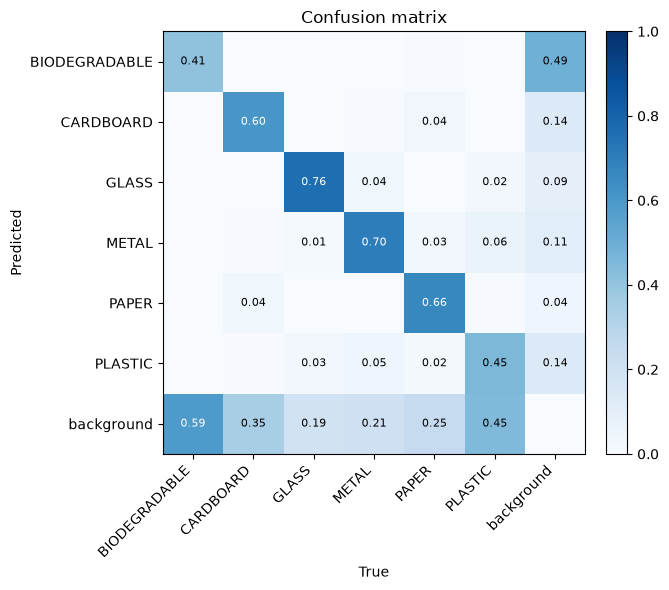

In [ ]:
# Confusion matrix
cm = metrics.confusion_matrix.matrix; labels = CLASSES + ["background"]
cmn = cm / (cm.sum(0, keepdims=True) + 1e-9)
fig, ax = plt.subplots(figsize=(7,6)); im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(7)); ax.set_xticklabels(labels, rotation=45, ha="right"); ax.set_xlabel("True")
ax.set_yticks(range(7)); ax.set_yticklabels(labels); ax.set_ylabel("Predicted")
for i in range(7):
    for j in range(7):
        if cmn[i,j] > 0.01: ax.text(j,i,f"{cmn[i,j]:.2f}",ha="center",va="center",fontsize=8,color="white" if cmn[i,j]>0.5 else "black")
fig.colorbar(im, fraction=0.046, pad=0.04); plt.title("Confusion matrix"); plt.tight_layout(); plt.show()

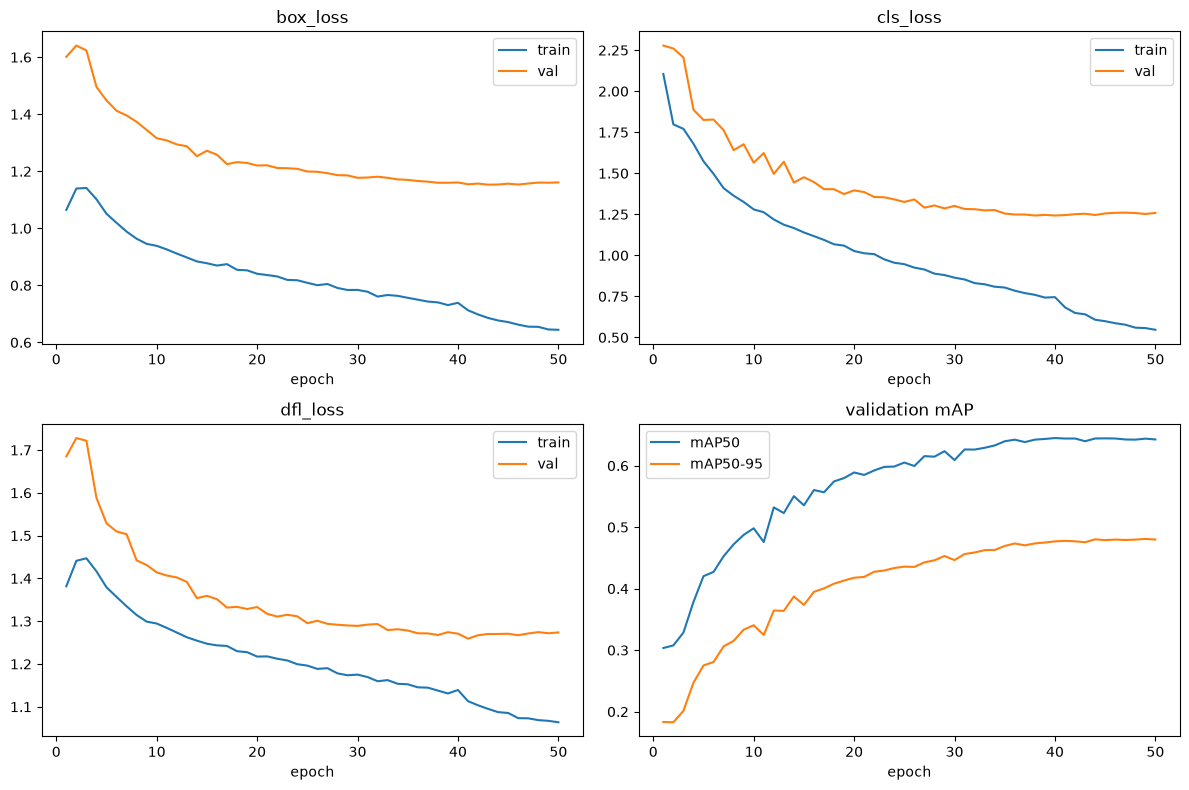

In [27]:
# Training curves from the run log (results.csv, provided from the Kaggle run):
# train vs val for each loss component, plus validation mAP.
hist = pd.read_csv("kaggle/output-balbio/runs/balbio/results.csv"); hist.columns = [c.strip() for c in hist.columns]
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
for a, comp in zip([ax[0][0], ax[0][1], ax[1][0]], ["box_loss", "cls_loss", "dfl_loss"]):
    a.plot(hist["epoch"], hist[f"train/{comp}"], label="train")
    a.plot(hist["epoch"], hist[f"val/{comp}"], label="val")
    a.set_xlabel("epoch"); a.set_title(comp); a.legend()
ax[1][1].plot(hist["epoch"], hist["metrics/mAP50(B)"], label="mAP50")
ax[1][1].plot(hist["epoch"], hist["metrics/mAP50-95(B)"], label="mAP50-95")
ax[1][1].set_xlabel("epoch"); ax[1][1].set_title("validation mAP"); ax[1][1].legend()
plt.tight_layout(); plt.show()

## Prediction

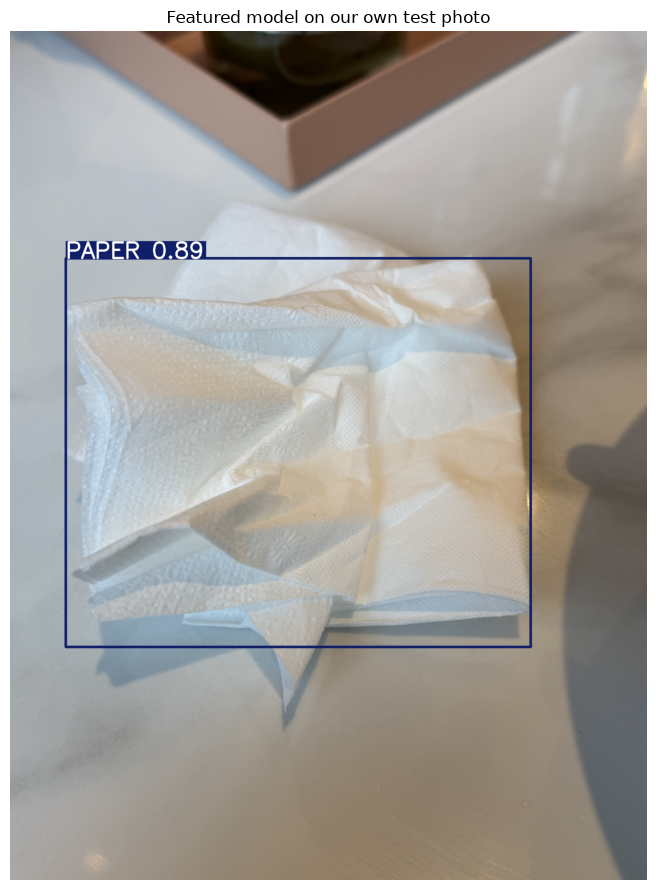

In [28]:
# Run the featured model on one of our own real-background test photos.
res = model.predict(str(TEST_IMG/"anh_03.jpg"), imgsz=640, conf=0.25, device=DEVICE, verbose=False)[0]
plt.figure(figsize=(7,9)); plt.imshow(res.plot()[:,:,::-1]); plt.axis("off")
plt.title("Featured model on our own test photo"); plt.tight_layout(); plt.show()

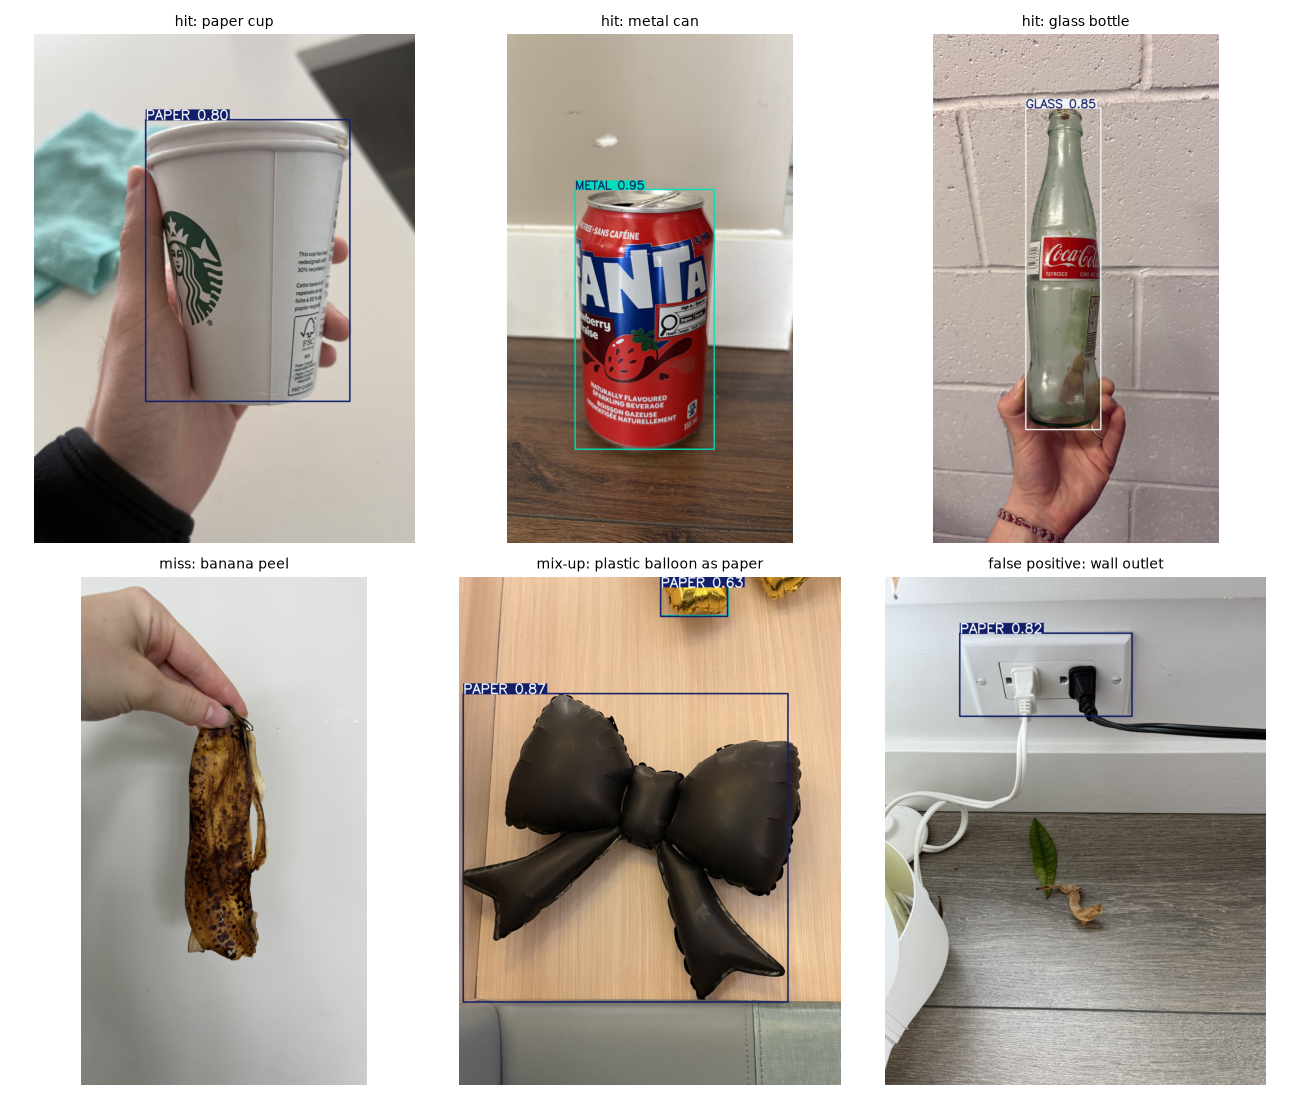

In [ ]:
# More predictions on our test photos: three hits, one miss, one mix-up, one false positive.
GRID = [("anh_04.jpg", "hit: paper cup"), ("agl_13.jpeg", "hit: metal can"),
        ("agl_27.jpeg", "hit: glass bottle"), ("agl_06.jpeg", "miss: banana peel"),
        ("anh_21.jpg", "mix-up: plastic balloon as paper"), ("anh_07.jpg", "false positive: wall outlet")]
fig, axes = plt.subplots(2, 3, figsize=(13, 11))
for ax, (name, note) in zip(axes.flat, GRID):
    r = model.predict(str(TEST_IMG/name), imgsz=640, conf=0.25, device=DEVICE, verbose=False)[0]
    ax.imshow(r.plot()[:,:,::-1]); ax.set_title(note, fontsize=10); ax.axis("off")
plt.tight_layout(); plt.show()

# Experiments and analysis

We tried four dataset compositions on the same cleaned base and evaluated all four on our own real test photos.

In [ ]:
# Evaluate all four models live on our test photos.
MODELS = {"baseline":"baseline.pt", "bio-swap":"bioswap.pt",
          "balanced-studio":"balanced_studio.pt", "balanced-bioswap":"balanced_bioswap.pt"}
labeled = [p.name for p in sorted(Path("dataset/images/test").iterdir())
           if p.suffix.lower() in (".jpg", ".jpeg") and (Path("dataset/labels/test")/(p.stem + ".txt")).exists()]
open("dataset/test_labeled.txt","w").write("\n".join(f"./images/test/{n}" for n in labeled))
open("testphotos.yaml","w").write(f"path: {Path('dataset').resolve()}\ntrain: test_labeled.txt\nval: test_labeled.txt\nnc: 6\nnames: {CLASSES}\n")
rows = []
for name, wf in MODELS.items():
    mt = YOLO(str(WEIGHTS_DIR/wf)).val(data="testphotos.yaml", split="val", device=DEVICE, plots=False, verbose=False)
    b = mt.box; idx = {int(c): i for i, c in enumerate(b.ap_class_index)}
    row = {"model": name, "mAP50": round(float(b.map50),3), "mAP50-95": round(float(b.map),3)}
    for c in range(6): row[CLASSES[c][:4]] = round(float(b.ap50[idx[c]]),3) if c in idx else 0.0
    rows.append(row)
pd.DataFrame(rows).set_index("model")

,mAP50,mAP50-95,BIOD,CARD,GLAS,META,PAPE,PLAS
model,,,,,,,,
baseline,0.284,0.252,0.079,0.126,0.213,0.519,0.364,0.401
bio-swap,0.275,0.242,0.359,0.070,0.071,0.468,0.316,0.364
balanced-studio,0.288,0.259,0.083,0.052,0.273,0.572,0.285,0.460
balanced-bioswap,0.345,0.304,0.220,0.052,0.274,0.625,0.417,0.483


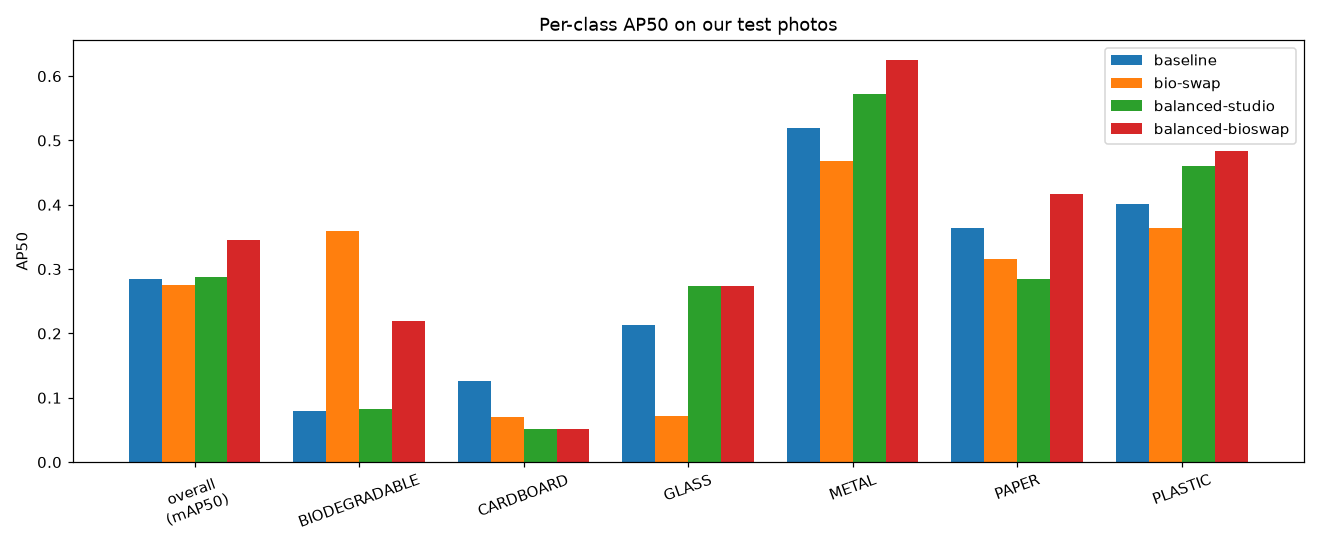

In [ ]:
# Chart
df = pd.DataFrame(rows).set_index("model")
cols = ["mAP50"] + [c[:4] for c in CLASSES]
x = np.arange(len(cols)); w = 0.2
plt.figure(figsize=(12, 5))
for k, (name, r) in enumerate(df.iterrows()):
    plt.bar(x + (k - 1.5) * w, [r[c] for c in cols], w, label=name)
plt.xticks(x, ["overall\n(mAP50)"] + CLASSES, rotation=20)
plt.ylabel("AP50"); plt.title("Per-class AP50 on our test photos")
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# Same four models on the test split we stratified from the online datasets (not our photos).
# This split's biodegradable is all white-studio food, so the BIODEGRADABLE column favors the studio-trained models.
open("onlinetest.yaml","w").write(f"path: {(DATASETS/'merged-6class').resolve()}\ntrain: train/images\nval: test/images\nnc: 6\nnames: {CLASSES}\n")
rows_online = []
for name, wf in MODELS.items():
    mt = YOLO(str(WEIGHTS_DIR/wf)).val(data="onlinetest.yaml", split="val", device=DEVICE, plots=False, verbose=False)
    b = mt.box; idx = {int(c): i for i, c in enumerate(b.ap_class_index)}
    row = {"model": name, "mAP50": round(float(b.map50),3), "mAP50-95": round(float(b.map),3)}
    for c in range(6): row[CLASSES[c][:4]] = round(float(b.ap50[idx[c]]),3) if c in idx else 0.0
    rows_online.append(row)
pd.DataFrame(rows_online).set_index("model")

,mAP50,mAP50-95,BIOD,CARD,GLAS,META,PAPE,PLAS
model,,,,,,,,
baseline,0.683,0.490,0.621,0.713,0.866,0.747,0.659,0.495
bio-swap,0.634,0.460,0.331,0.696,0.841,0.751,0.656,0.530
balanced-studio,0.595,0.441,0.458,0.663,0.865,0.737,0.415,0.436
balanced-bioswap,0.508,0.388,0.151,0.638,0.812,0.687,0.358,0.399


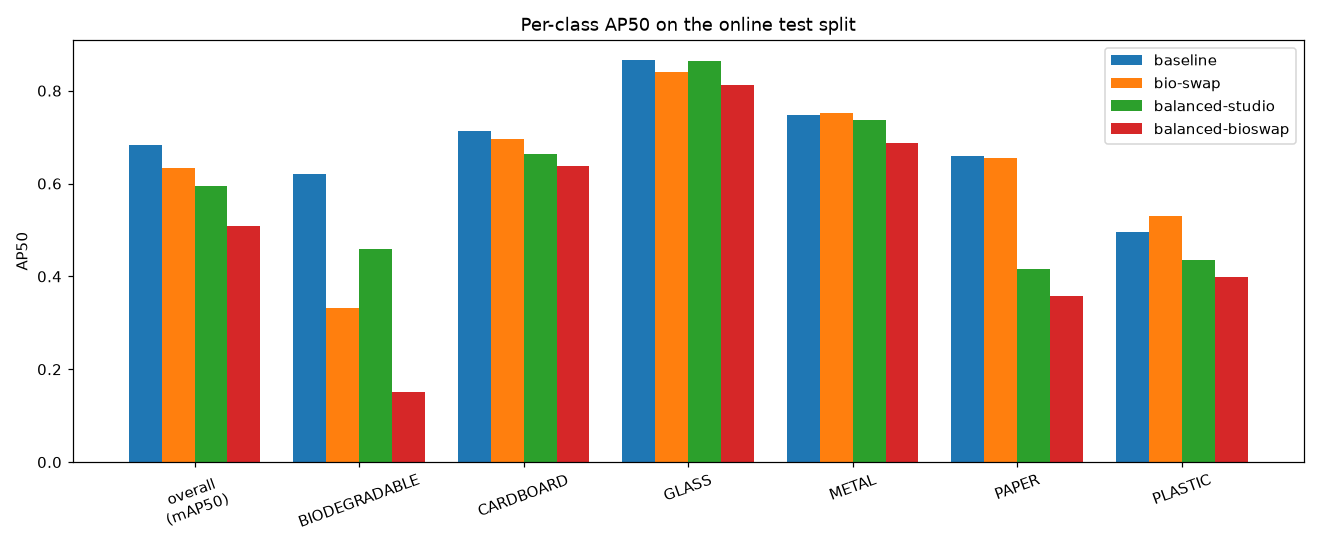

In [ ]:
# The online test split comparison as a chart.
df_online = pd.DataFrame(rows_online).set_index("model")
cols = ["mAP50"] + [c[:4] for c in CLASSES]
x = np.arange(len(cols)); w = 0.2
plt.figure(figsize=(12, 5))
for k, (name, r) in enumerate(df_online.iterrows()):
    plt.bar(x + (k - 1.5) * w, [r[c] for c in cols], w, label=name)
plt.xticks(x, ["overall\n(mAP50)"] + CLASSES, rotation=20)
plt.ylabel("AP50"); plt.title("Per-class AP50 on the online test split")
plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# The same non-bio images as the split above, but biodegradable comes from held-out real-food images instead.
open("bioswaptest.yaml","w").write(f"path: {(DATASETS/'bioswap-test').resolve()}\ntrain: images\nval: images\nnc: 6\nnames: {CLASSES}\n")
rows_bioswap = []
for name, wf in MODELS.items():
    mt = YOLO(str(WEIGHTS_DIR/wf)).val(data="bioswaptest.yaml", split="val", device=DEVICE, plots=False, verbose=False)
    b = mt.box; idx = {int(c): i for i, c in enumerate(b.ap_class_index)}
    row = {"model": name, "mAP50": round(float(b.map50),3), "mAP50-95": round(float(b.map),3)}
    for c in range(6): row[CLASSES[c][:4]] = round(float(b.ap50[idx[c]]),3) if c in idx else 0.0
    rows_bioswap.append(row)
pd.DataFrame(rows_bioswap).set_index("model")

,mAP50,mAP50-95,BIOD,CARD,GLAS,META,PAPE,PLAS
model,,,,,,,,
baseline,0.588,0.442,0.110,0.718,0.883,0.754,0.580,0.485
bio-swap,0.742,0.535,0.834,0.708,0.870,0.801,0.676,0.560
balanced-studio,0.525,0.406,0.091,0.667,0.879,0.755,0.341,0.418
balanced-bioswap,0.585,0.434,0.471,0.657,0.848,0.734,0.378,0.423


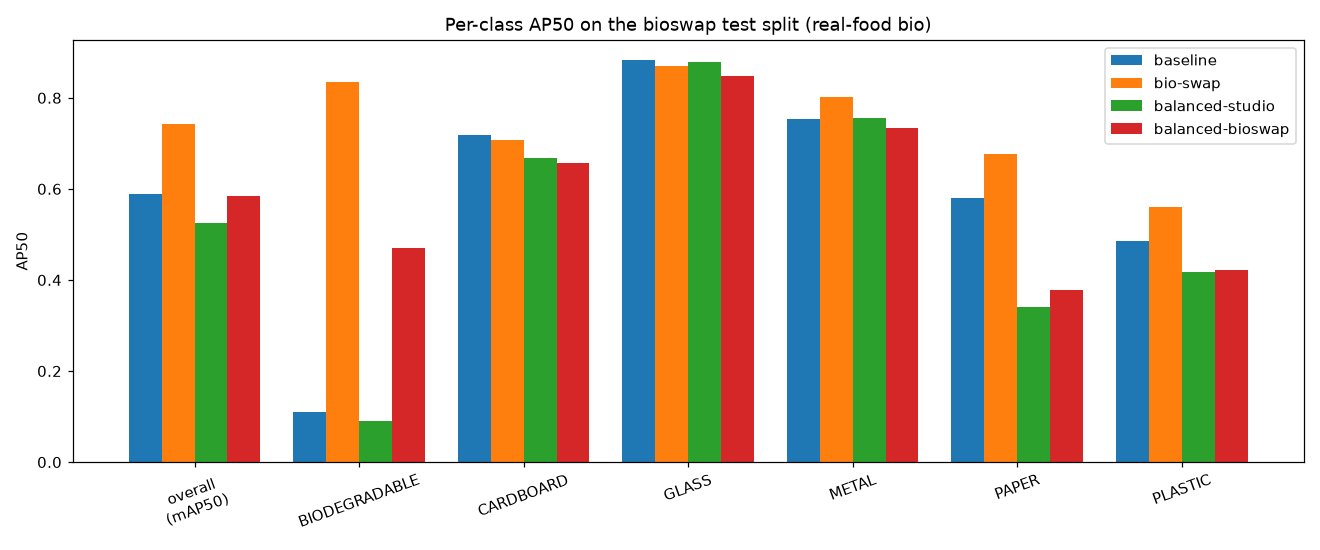

In [ ]:
# The bioswap test comparison as a chart.
df_bioswap = pd.DataFrame(rows_bioswap).set_index("model")
cols = ["mAP50"] + [c[:4] for c in CLASSES]
x = np.arange(len(cols)); w = 0.2
plt.figure(figsize=(12, 5))
for k, (name, r) in enumerate(df_bioswap.iterrows()):
    plt.bar(x + (k - 1.5) * w, [r[c] for c in cols], w, label=name)
plt.xticks(x, ["overall\n(mAP50)"] + CLASSES, rotation=20)
plt.ylabel("AP50"); plt.title("Per-class AP50 on the bioswap test split (real-food bio)")
plt.legend(); plt.tight_layout(); plt.show()

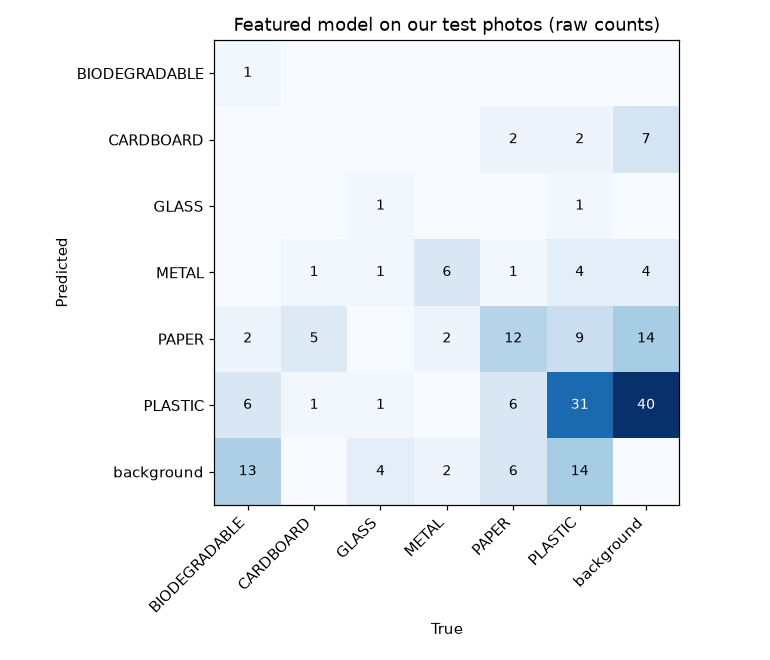

In [ ]:
# Confusion matrix on our own test photos.
# Raw counts because with only ~134 boxes, percentages would overstate single mistakes.
mt = YOLO(str(WEIGHTS_DIR/"balanced_bioswap.pt")).val(data="testphotos.yaml", split="val", device=DEVICE, plots=True, verbose=False)
cm = mt.confusion_matrix.matrix.astype(int)
labels = CLASSES + ["background"]
fig, ax = plt.subplots(figsize=(7,6)); im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(7)); ax.set_xticklabels(labels, rotation=45, ha="right"); ax.set_xlabel("True")
ax.set_yticks(range(7)); ax.set_yticklabels(labels); ax.set_ylabel("Predicted")
for i in range(7):
    for j in range(7):
        if cm[i,j]: ax.text(j,i,cm[i,j],ha="center",va="center",fontsize=9,color="white" if cm[i,j]>cm.max()/2 else "black")
plt.title("Featured model on our test photos (raw counts)"); plt.tight_layout(); plt.show()

## Analysis

- Studio validation is misleading because the baseline scores about 0.70 mAP50 on white-studio validation but only about 0.20 on our real photos.
- On the reviewed test labels balanced-bioswap wins clearly (0.345 mAP50 vs 0.288 for the next best), leading four of the six classes.
- Models trained on studio food photos barely detect real food waste (AP50 ~0.08), while swapping in real-food data lifts it to ~0.36.
- Class balancing on studio data hurt overall mAP without helping the minority classes, because downsampling removed data that also contained minority instances.
- The confusion matrix shows the errors are mostly missed objects and false detections (the background row and column), plus paper vs plastic mix-ups. At the default confidence threshold the featured model missed 13 of the 22 biodegradable boxes.
- Answering the metrics question from the Evaluation section: for a bin-sorting assistant precision matters most, because a false detection can put an item in the wrong bin and contaminate a recycling stream, while a missed detection just falls back to the person deciding.
- Precise localization matters least, a rough box is enough to point at the item, so we compare models on mAP50 rather than the stricter mAP50-95.
- We chose to keep the balanced-bioswap as the featured model to show the full pipeline including balancing, and on the full 108-photo test set it is also the top performer. bio-swap (without balancing) remains stronger on the online real-food test and on the biodegradable class.